# Model fitting 2: Only SSC, MCMC without minimizer step and ultranest backend with Open MPI

In [1]:
#import warnings
#warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
import jetset
from jetset.test_data_helper import  test_SEDs
from jetset.data_loader import ObsData,Data
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs

In [2]:
print(jetset.__version__)

1.4.0rc3


In [3]:
test_SEDs

['/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_3C345.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_ABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_DEABS.ecsv']

## Loading data



In [4]:
print(test_SEDs[1])
data=Data.from_file(test_SEDs[1])


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv



***  binning data  ***
---> N bins= 88
---> bin_width= 0.2



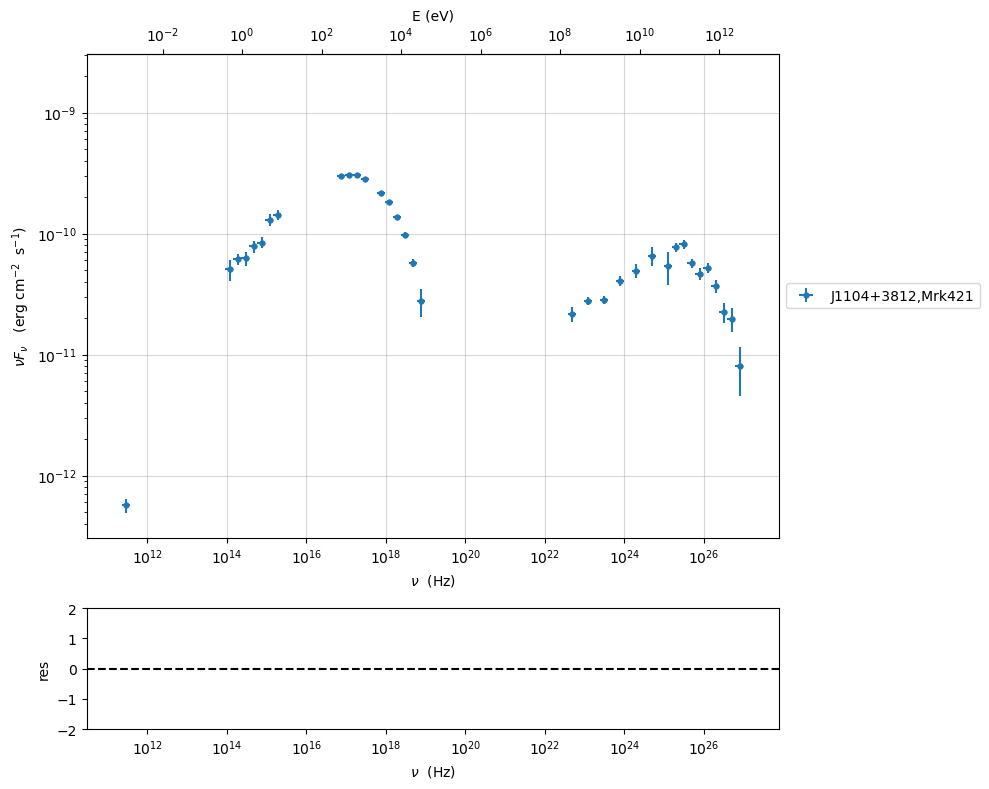

In [5]:
%matplotlib inline
sed_data=ObsData(data_table=data)
sed_data.group_data(bin_width=0.2)

sed_data.add_systematics(0.1,[10.**6,10.**16])
p=sed_data.plot_sed()
#p.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

In [6]:
sed_data.save('Mrk_401.pkl')

## creating and setting the sampler

In [7]:
from jetset.mcmc_ultranest import UltraNestSampler
from jetset.minimizer import ModelMinimizer


In [8]:
from jetset.jet_model import Jet
from jetset.model_manager import FitModel
fit_model=FitModel(jet=Jet(emitters_distribution='plc'),name='plain_plc')

/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/model_manager.py:259: UserWarning: no cosmology defined, using the one from jet FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
  warnings.warn(m)


We create a `ModelMinimizer` object directly for the MCMC step, skipping the `.run()` method, replaced by the call of the `prepare_fit` method.

In [9]:
model_minimizer = model_minimizer=ModelMinimizer('mcmc')
model_minimizer.prepare_fit(fit_model,
                            sed_data,
                            nu_fit_start=1E11,
                            nu_fit_stop=1E29,
                            use_UL=True)



filtering data in fit range = [1.000000e+11,1.000000e+29]
data length 34


to speed up the utlranest sampler we make parameters logarithmic:

In [10]:
model_minimizer.fit_model.jet_leptonic.parameters.R.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.B.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.N.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.gmax.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.gmin.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.gamma_cut.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.z_cosm.freeze()


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/model_parameters.py:977: RuntimeWarning: divide by zero encountered in log10
  return np.log10(v)


In [11]:
model_minimizer.fit_model.name

'plain_plc'

In [12]:
model_minimizer.fit_model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,1.569897e+01,3.000000e+00,3.000000e+01,True,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,-1.000000e+00,-inf,--,True,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,1.000000e-01,0.000000e+00,--,False,True
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.010300e-01,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,6.000000e+00,0.000000e+00,1.500000e+01,True,False
jet_leptonic,N,emitters_density,1 / cm3,2.000000e+00,-inf,--,True,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,4.000000e+00,0.000000e+00,9.000000e+00,True,False


None

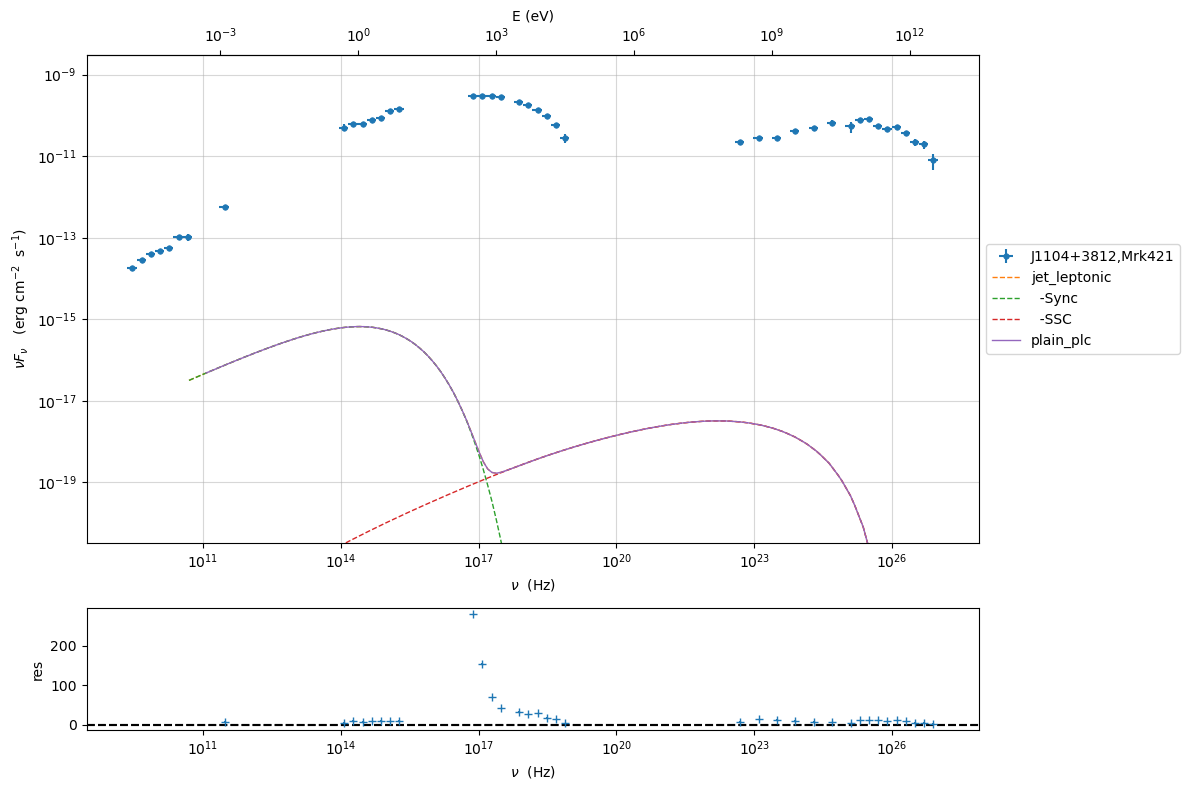

In [13]:
model_minimizer.fit_model.eval()
p=model_minimizer.fit_model.plot_model(sed_data=sed_data)

In [14]:

mcmc=UltraNestSampler(model_minimizer)

In [15]:
mcmc.model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.010300e-01,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,6.000000e+00,0.000000e+00,1.500000e+01,True,False
jet_leptonic,N,emitters_density,1 / cm3,2.000000e+00,-inf,--,True,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,4.000000e+00,0.000000e+00,9.000000e+00,True,False
jet_leptonic,p,LE_spectral_slope,,2.000000e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,R,region_size,cm,1.569897e+01,3.000000e+00,3.000000e+01,True,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,-1.000000e+00,-inf,--,True,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False


None

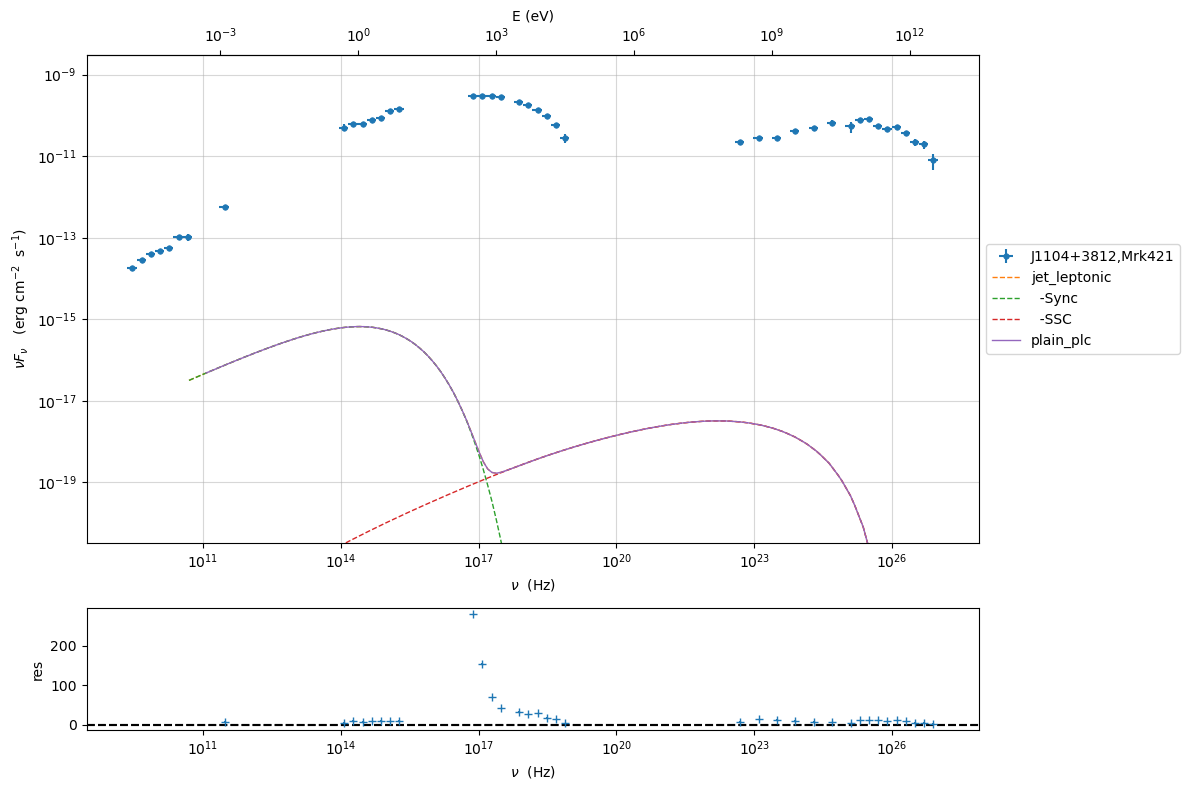

In [16]:
mcmc.model.eval()
mcmc.model.plot_model(sed_data=sed_data)

You can inspect the mcmc parameters using:

In [17]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,3.010300e-01,True,3.010300e-01,--,--,--,0.000000e+00,9.000000e+00,False
jet_leptonic,gmax,6.000000e+00,True,6.000000e+00,--,--,--,0.000000e+00,1.500000e+01,False
jet_leptonic,N,2.000000e+00,True,2.000000e+00,--,--,--,-inf,--,False
jet_leptonic,gamma_cut,4.000000e+00,True,4.000000e+00,--,--,--,0.000000e+00,9.000000e+00,False
jet_leptonic,p,2.000000e+00,False,2.000000e+00,--,--,--,-1.000000e+01,1.000000e+01,False
jet_leptonic,R,1.569897e+01,True,1.569897e+01,--,--,--,3.000000e+00,3.000000e+01,False
jet_leptonic,B,-1.000000e+00,True,-1.000000e+00,--,--,--,-inf,--,False
jet_leptonic,beam_obj,1.000000e+01,False,1.000000e+01,--,--,--,1.000000e-04,--,False
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


In [18]:
mcmc.model.parameters.best_fit_par_table

model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
str12,str16,float64,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,3.010300e-01,--,--,--,3.010300e-01,0.000000e+00,9.000000e+00,False
jet_leptonic,gmax,6.000000e+00,--,--,--,6.000000e+00,0.000000e+00,1.500000e+01,False
jet_leptonic,N,2.000000e+00,--,--,--,2.000000e+00,-inf,--,False
jet_leptonic,gamma_cut,4.000000e+00,--,--,--,4.000000e+00,0.000000e+00,9.000000e+00,False
jet_leptonic,p,2.000000e+00,--,--,--,2.000000e+00,-1.000000e+01,1.000000e+01,False
jet_leptonic,R,1.569897e+01,--,--,--,1.569897e+01,3.000000e+00,3.000000e+01,False
jet_leptonic,R_H,1.000000e+17,--,--,--,1.000000e+17,0.000000e+00,--,True
jet_leptonic,B,-1.000000e+00,--,--,--,-1.000000e+00,-inf,--,False
jet_leptonic,NH_cold_to_rel_e,1.000000e+00,--,--,--,1.000000e+00,0.000000e+00,--,True


If you want to exclude or include parameters from the samplers just freeze/free them, and set parameters bounds for sampler 

In [19]:
mcmc.model.jet_leptonic.parameters.gmax.freeze() #this parameter si excluded from the sampler
mcmc.model.jet_leptonic.parameters.gmax.val=7

mcmc.set_bounds(par_name='p',comp_name='jet_leptonic',par_bounds=[1.5,3.5])
mcmc.set_bounds(par_name='N',comp_name='jet_leptonic',par_bounds=[-3,3])
mcmc.set_bounds(par_name='R',comp_name='jet_leptonic',par_bounds=[15,17])
mcmc.set_bounds(par_name='beam_obj',comp_name='jet_leptonic',par_bounds=[10,50])


mcmc.set_bounds(par_name='gmin',comp_name='jet_leptonic',par_bounds=[0,3.3])
mcmc.set_bounds(par_name='gamma_cut',comp_name='jet_leptonic',par_bounds=[3,6])
mcmc.set_bounds(par_name='B',comp_name='jet_leptonic',par_bounds=[-3,0])
 


par: p  ref value:  2.0  mcmc bounds: [1.5, 3.5]
par: N  ref value:  2.0  mcmc bounds: [np.float64(-3.0), np.float64(3.0)]
par: R  ref value:  15.698970004336019  mcmc bounds: [np.float64(15.0), np.float64(17.0)]
par: beam_obj  ref value:  10.0  mcmc bounds: [10, 50]
par: gmin  ref value:  0.3010299956639812  mcmc bounds: [np.float64(0.0), np.float64(3.3)]
par: gamma_cut  ref value:  4.0  mcmc bounds: [np.float64(3.0), np.float64(6.0)]
par: B  ref value:  -1.0  mcmc bounds: [np.float64(-3.0), np.float64(0.0)]


In [20]:
mcmc.model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.010300e-01,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,7.000000e+00,0.000000e+00,1.500000e+01,True,True
jet_leptonic,N,emitters_density,1 / cm3,2.000000e+00,-inf,--,True,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,4.000000e+00,0.000000e+00,9.000000e+00,True,False
jet_leptonic,p,LE_spectral_slope,,2.000000e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,R,region_size,cm,1.569897e+01,3.000000e+00,3.000000e+01,True,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,-1.000000e+00,-inf,--,True,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False


None

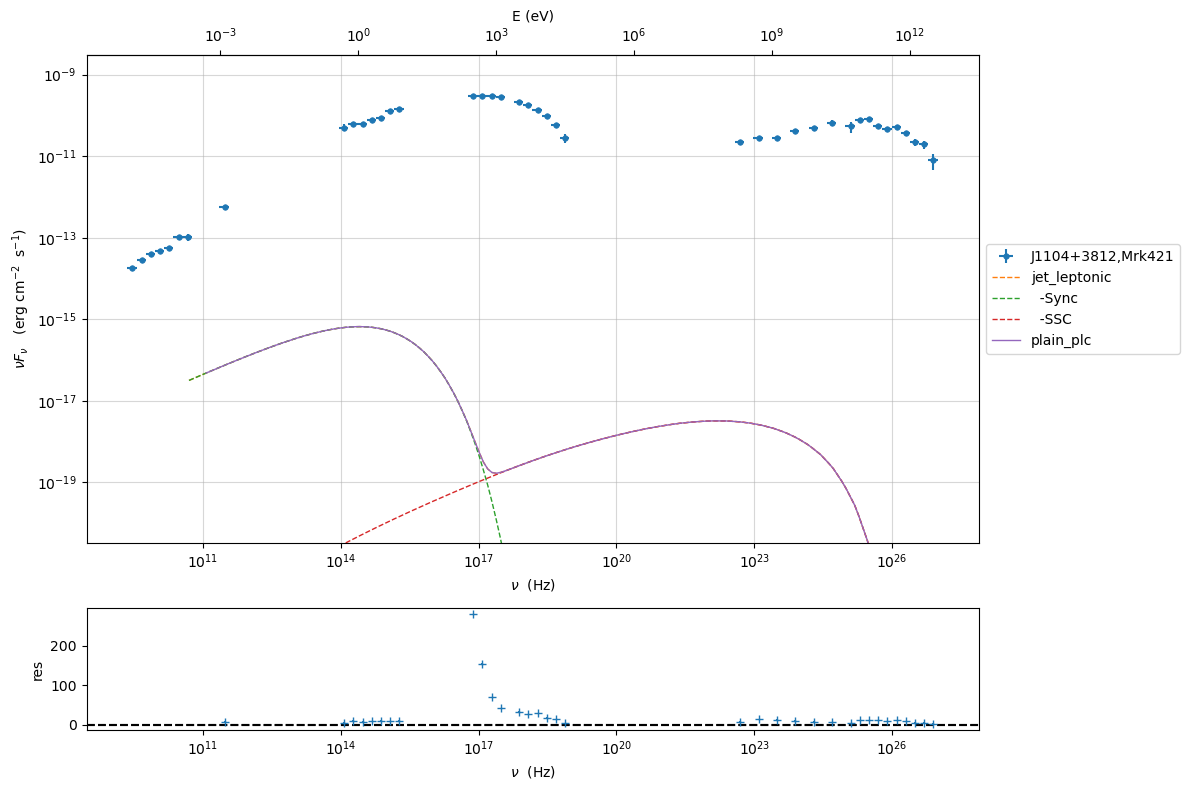

In [21]:
mcmc.model.eval()
mcmc.model.plot_model(sed_data=sed_data)

In [22]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,3.010300e-01,True,3.010300e-01,--,--,--,0.000000e+00,3.300000e+00,False
jet_leptonic,N,2.000000e+00,True,2.000000e+00,--,--,--,-3.000000e+00,3.000000e+00,False
jet_leptonic,gamma_cut,4.000000e+00,True,4.000000e+00,--,--,--,3.000000e+00,6.000000e+00,False
jet_leptonic,p,2.000000e+00,False,2.000000e+00,--,--,--,1.500000e+00,3.500000e+00,False
jet_leptonic,R,1.569897e+01,True,1.569897e+01,--,--,--,1.500000e+01,1.700000e+01,False
jet_leptonic,B,-1.000000e+00,True,-1.000000e+00,--,--,--,-3.000000e+00,0.000000e+00,False
jet_leptonic,beam_obj,1.000000e+01,False,1.000000e+01,--,--,--,1.000000e+01,5.000000e+01,False
jet_leptonic,gmax,7.000000e+00,True,--,--,--,--,0.000000e+00,1.500000e+01,True
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


## Running the sampler

The parameter `ultranest_output_dir`, by default, will be set to `f'ultranest_{self.model.name}'`. You can override it by passing the desired name

In [23]:
mcmc.model.jet_leptonic.set_num_c_threads()
mcmc.run_sampler(min_num_live_points=64,
                 nsteps=1,
                 max_num_improvement_loops=1,
                 ultranest_output_dir='ultranest_run', #to override the local directory storing the ultranest products, to be inspected if needed 
                 min_ess=100)



Creating directory for new run ultranest_run/run10
ultranest run starting

[ultranest] Sampling 64 live points from prior ...


[ultranest] Found 1 clusters, but only have 64 live points, want 80.


[ultranest] Explored until L=-6e+04  


[ultranest] Likelihood function evaluations: 378


[ultranest] Writing samples and results to disk ...


...

[ultranest] Writing samples and results to disk ...


[ultranest] Writing samples and results to disk ... done


[ultranest] Reached maximum number of improvement loops.


[ultranest] done iterating.


ultranest run done, took 85.76 seconds
----------------------------
UltraNest best fit solution
comp: jet_leptonic par: gmin ultranest best fit val: 2.6948157338803784 quantiles(0.16,0.5,0.84): [2.71278188 2.77709755 2.83226894]
comp: jet_leptonic par: N ultranest best fit val: 0.10816057550027569 quantiles(0.16,0.5,0.84): [-0.39829494 -0.23205761 -0.03992518]
comp: jet_leptonic par: gamma_cut ultranest best fit val: 5.167610867867785 quantiles(0.16,0.5,0.84): [5.20642819 5.24426723 5.29172049]
comp: jet_leptonic par: p ultranest best fit val: 2.1895770297753576 quantiles(0.16,0.5,0.84): [2.16826915 2.19091794 2.21147363]
comp: jet_leptonic par: R ultranest best fit val: 16.338546031091596 quantiles(0.16,0.5,0.84): [16.45473688 16.56095571 16.66554645]
comp: jet_leptonic par: B ultranest best fit val: -1.1058281549828641 quantiles(0.16,0.5,0.84): [-1.25719809 -1.1749074  -1.1187011 ]
comp: jet_leptonic par: beam_obj ultranest best fit val: 46.138927919163635 quantiles(0.16,0.5,0.84): [

In [24]:
mcmc.sampler.print_results()


logZ = -43.715 +- 0.804
  single instance: logZ = -43.715 +- 0.606
  bootstrapped   : logZ = -43.733 +- 0.804
  tail           : logZ = +- 0.007
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump distance 0.47 (should be >1), far enough fraction: 9.90% : very fishy. Double nsteps and see if fraction and lnZ change)

    gmin                : 2.532 │ ▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▇▇▆▇▇▇▇▇▄▄▃▂▁▂▁▁▁▁▁▁ ▁ │3.017     2.776 +- 0.064
    N                   : -0.82 │ ▁▁▁▁ ▂▂▁▂▂▃▂▃▅▄▇▅▅▆▆▄▄▂▄▂▂▂▁▁▁▁▁▁▁▁▁▁ │0.44      -0.23 +- 0.18
    gamma_cut           : 5.042 │ ▁ ▁ ▁▁▁▁▁▁▂▁▂▃▂▃▅▇▇▅▇▆▆▅▃▂▃▂▂▂▂▁▁▁ ▁▁ │5.415     5.245 +- 0.049
    p                   : 2.093 │ ▁     ▁▁▁▁▂▁▂▃▃▅▅▄▅▅▆▇▆▅▅▄▃▂▂▁▂▁▁▁  ▁ │2.269     2.190 +- 0.022
    R                   : 16.18 │ ▁▁▁▁ ▁▁▁▁▂▂▃▂▄▆▄▅▆▇▅▇▇▅▅▄▄▃▂▂▂▂▂▂ ▁▁▁ │16.89     16.56 +- 0.11
    B                   : -1.448│ ▁▁▁▁▁▁▂▂▂▂▁▂▃▄▄▄▅▆▇▇▇▅▅▄▂▁▁▂▁▁▁▁▁▁▁ ▁ │-0.898    -1.181 +- 0.073
    beam_obj            : 30.5  │ ▁▁▁▃▅▆▅▅▄▄▆▇▄▆▂

[<Figure size 1000x2100 with 7 Axes>]

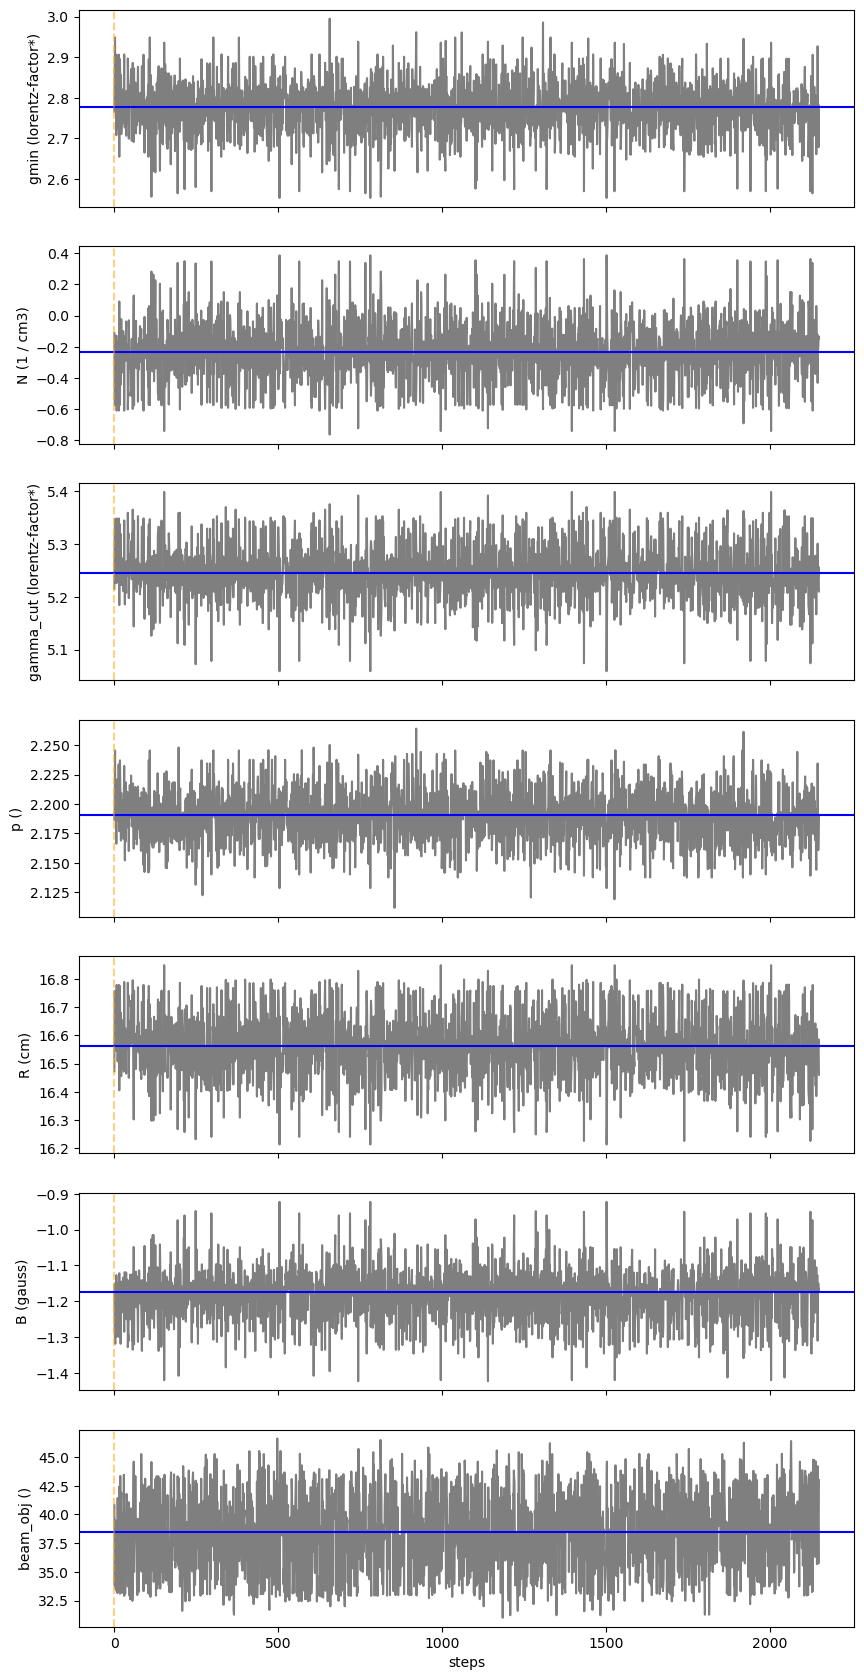

In [25]:
mcmc.plot_chain()

In [26]:
#mcmc.tune_burnin(tau_cor_coeff=4)

Showing the MCMC parameters. Now MCMC bestfit values are updated to the best-fit MCMC solution


In [27]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,2.694816e+00,True,2.694816e+00,2.712782e+00,2.777098e+00,2.832269e+00,0.000000e+00,3.300000e+00,False
jet_leptonic,N,1.081606e-01,True,1.081606e-01,-3.982949e-01,-2.320576e-01,-3.992518e-02,-3.000000e+00,3.000000e+00,False
jet_leptonic,gamma_cut,5.167611e+00,True,5.167611e+00,5.206428e+00,5.244267e+00,5.291720e+00,3.000000e+00,6.000000e+00,False
jet_leptonic,p,2.189577e+00,False,2.189577e+00,2.168269e+00,2.190918e+00,2.211474e+00,1.500000e+00,3.500000e+00,False
jet_leptonic,R,1.633855e+01,True,1.633855e+01,1.645474e+01,1.656096e+01,1.666555e+01,1.500000e+01,1.700000e+01,False
jet_leptonic,B,-1.105828e+00,True,-1.105828e+00,-1.257198e+00,-1.174907e+00,-1.118701e+00,-3.000000e+00,0.000000e+00,False
jet_leptonic,beam_obj,4.613893e+01,False,4.613893e+01,3.428849e+01,3.847084e+01,4.224848e+01,1.000000e+01,5.000000e+01,False
jet_leptonic,gmax,7.000000e+00,True,--,--,--,--,0.000000e+00,1.500000e+01,True
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


### plotting the posterior corner plot

To have a better rendering on the scatter plot, we redefine the plot labels

In [28]:
mcmc.set_plot_label('N',r'log($N$)',comp_name='jet_leptonic')
mcmc.set_plot_label('R',r'log($R$)',comp_name='jet_leptonic')
mcmc.set_plot_label('B',r'log($B$)',comp_name='jet_leptonic')

mcmc.set_plot_label('gmin',r'log($\gamma_{\rm min}$)',comp_name='jet_leptonic')
mcmc.set_plot_label('p',r'$p$',comp_name='jet_leptonic')
#mcmc.set_plot_label('r',r'$r$',comp_name='jet_leptonic')
mcmc.set_plot_label('gamma_cut',r'$\gamma_{\rm cut}$',comp_name='jet_leptonic')
mcmc.set_plot_label('beam_obj',r'$\delta$',comp_name='jet_leptonic')



the code below lets you tuning the output

1) mpl.rcParams['figure.dpi'] if you increase it you get a better definition
2) title_fmt=".2E" this is the format for python, 2 significant digits, scientific notation
3) title_kwargs=dict(fontsize=12) you can change the fontsize

Per-component corner plot

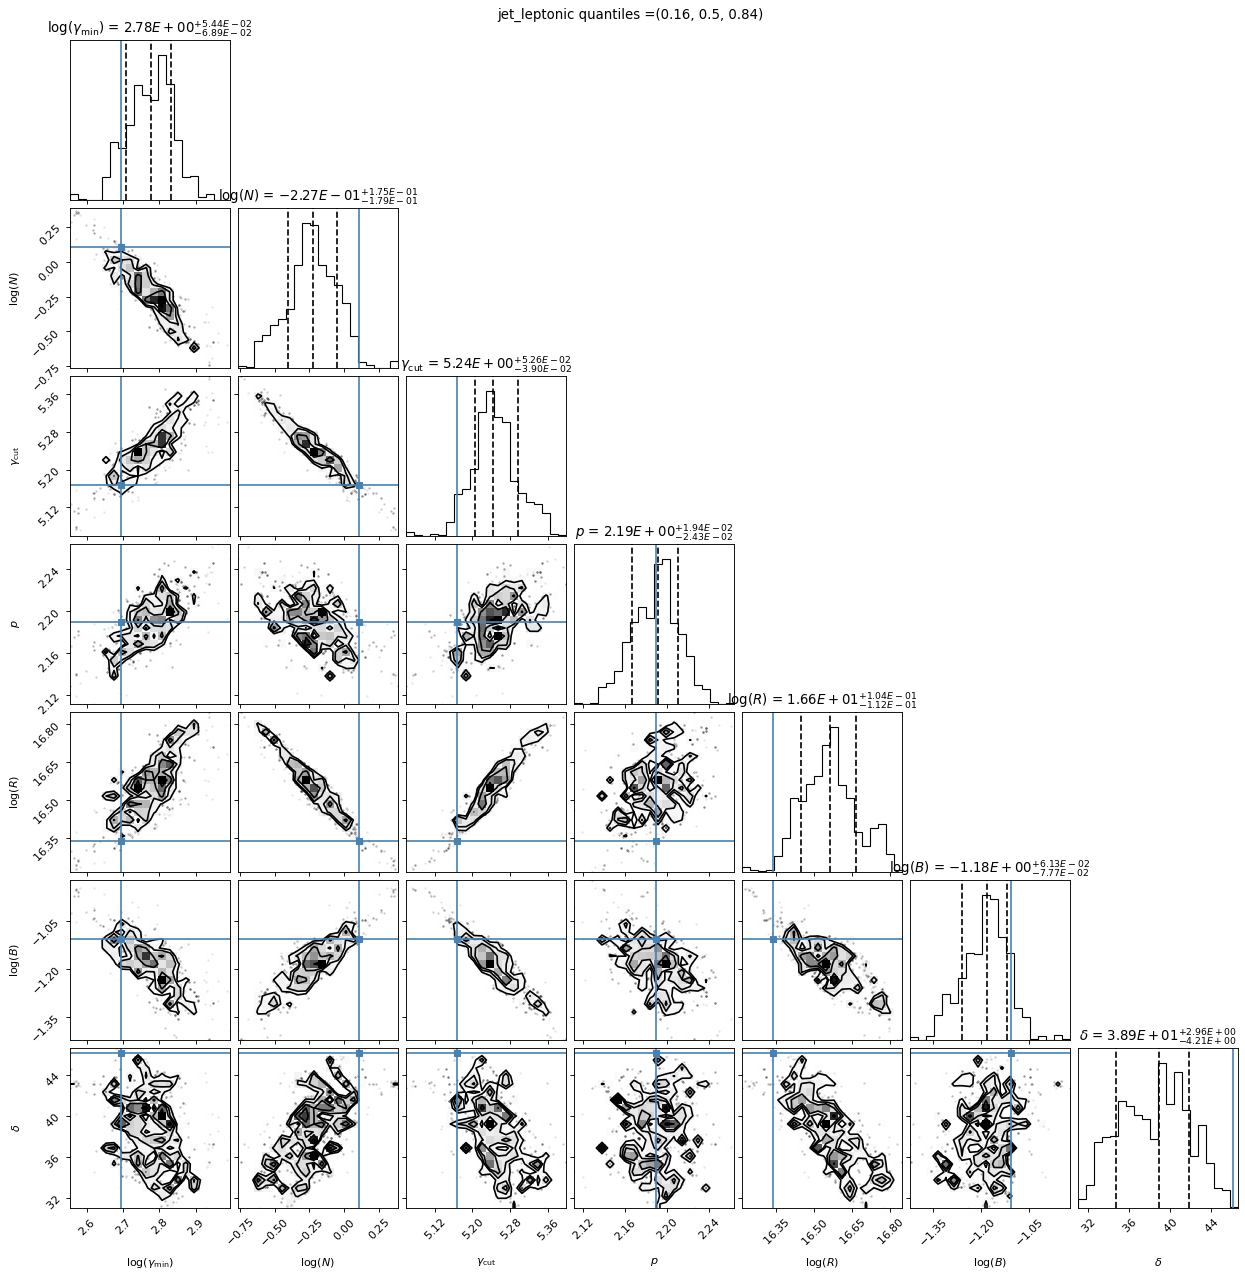

In [29]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

Global corner plot, pass `per_component=False`


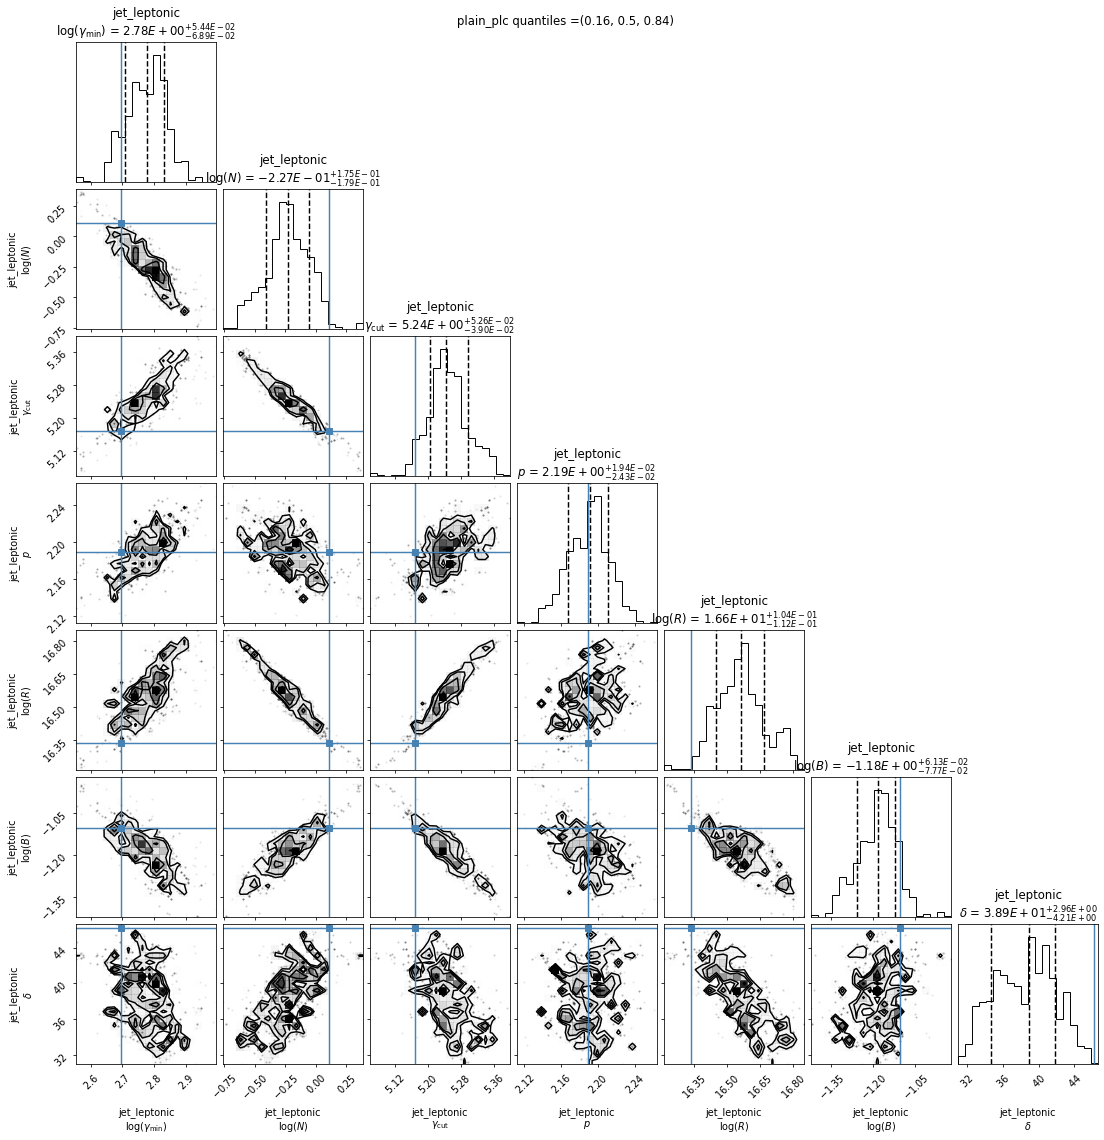

In [30]:
mpl.rcParams['figure.dpi'] = 70
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True,per_component=False)

### plotting the model

To plot the sampled model range against the input mcmc best-fit model

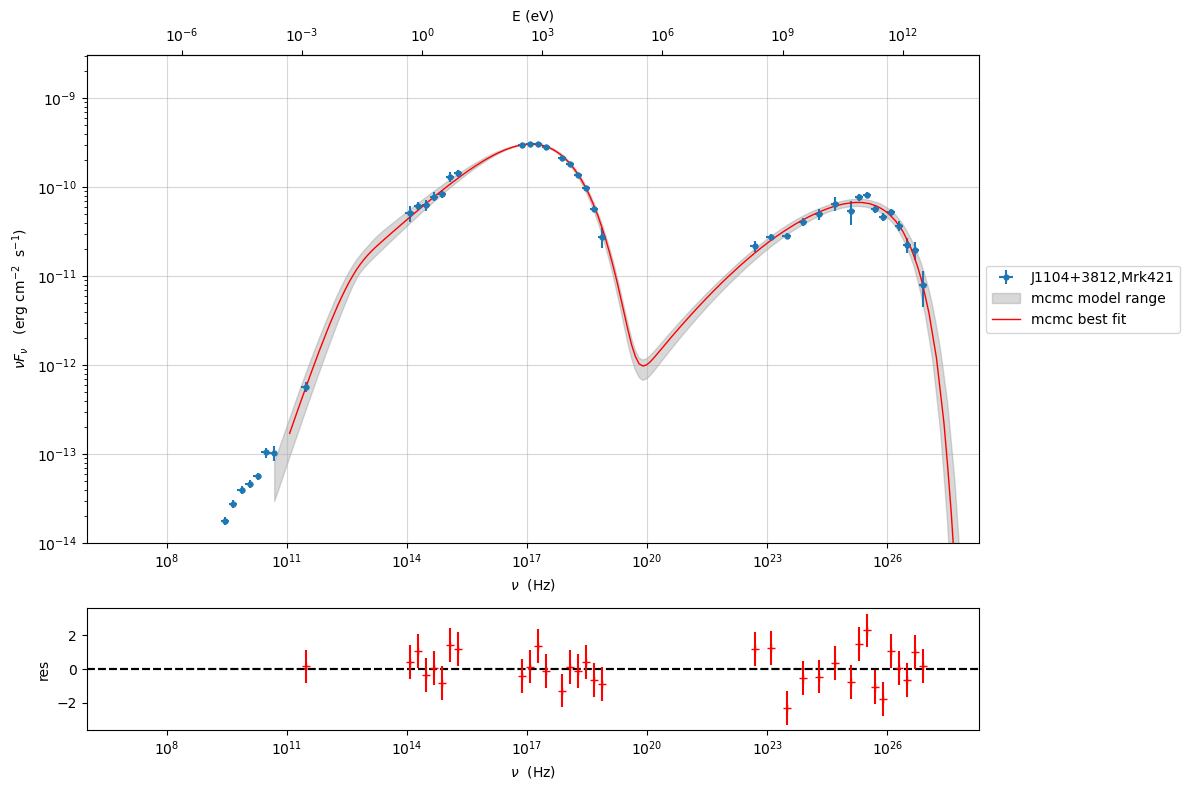

In [31]:

from jetset.data_loader import ObsData
sed_data=ObsData.load('Mrk_401.pkl')
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=600)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the mcmc best-fit model providing quantiles. The size parameter defines the number of samples to use to extract the quantiles. I am using a size equal to the number of steps

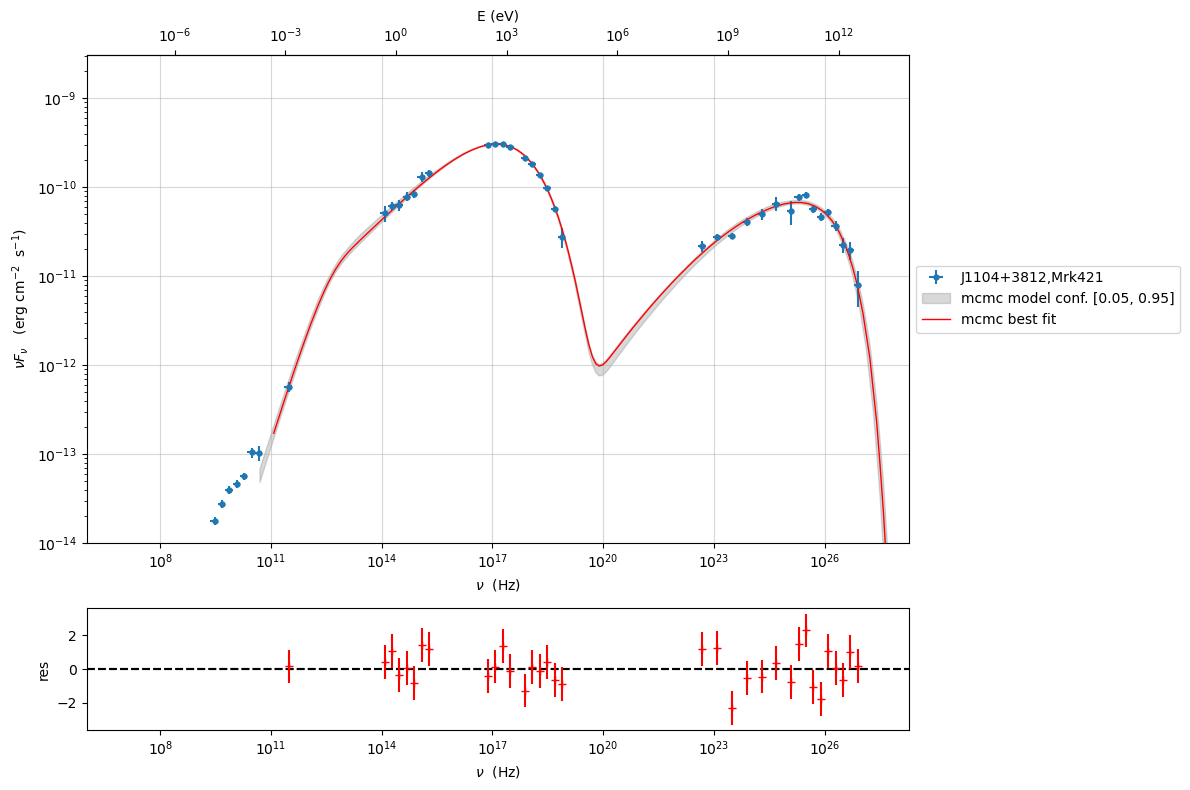

In [32]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95])
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

If you want to plot also the model components, pass the argument `plot_components=True`

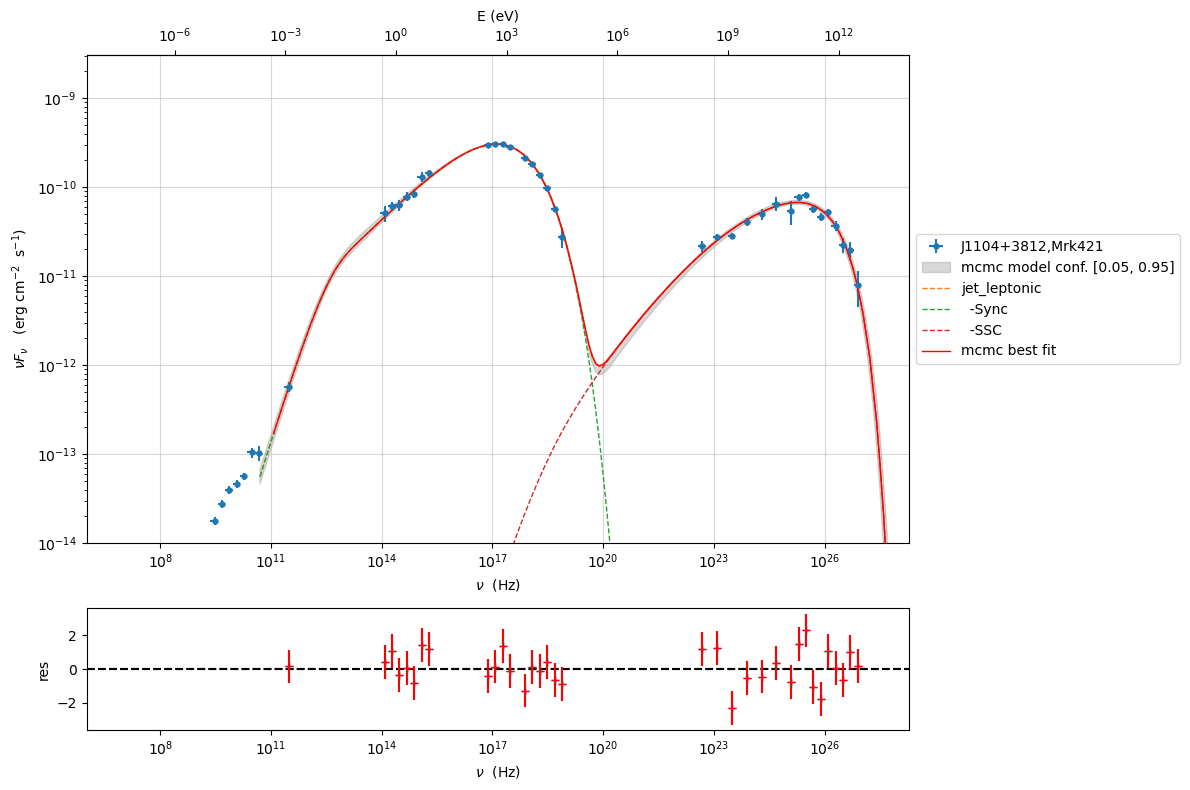

In [33]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)


To plot the frequentist  best-fit  model range,p roviding quantiles, provide (``plot_mcmc_best_fit_model=False``)

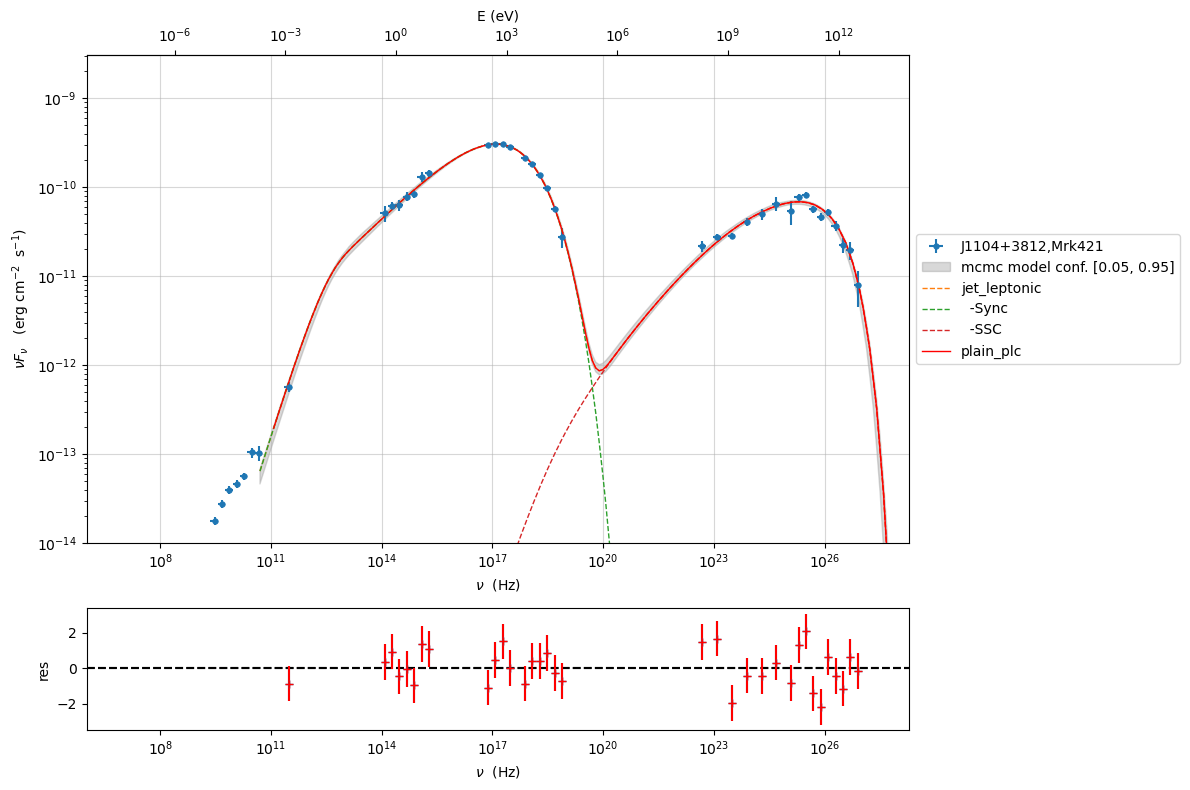

In [34]:
mpl.rcParams['figure.dpi'] = 100
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95], plot_mcmc_best_fit_model=False,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

### plotting chains and individual posteriors

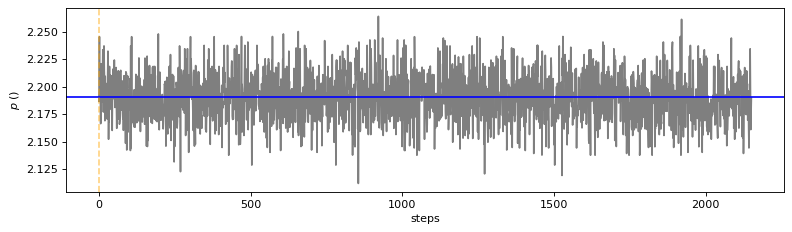

In [35]:
import matplotlib.pylab as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(par_name='p',log_plot=False)
plt.tight_layout()

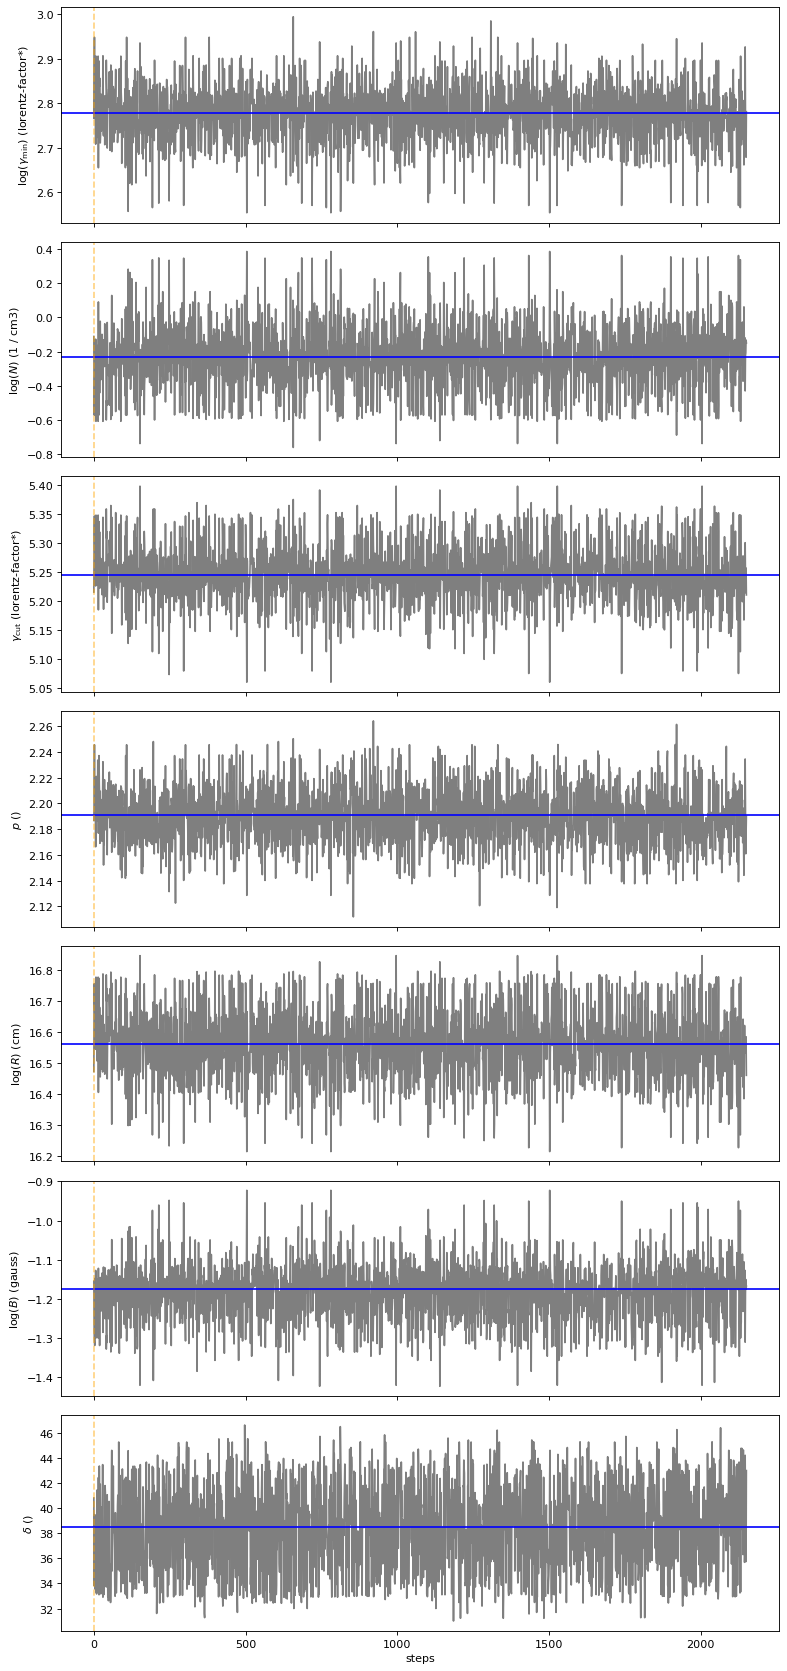

In [36]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(log_plot=False)
plt.tight_layout()

## Saving and reloading the sampler

In [37]:
mcmc.save('mcmc_sampler_ultranest_plain.pkl')

In [38]:
from jetset.mcmc import McmcSampler
from jetset.data_loader import ObsData

sed_data=ObsData.load('Mrk_401.pkl')
ms=McmcSampler.load('mcmc_sampler_ultranest_plain.pkl')

import matplotlib as mpl


In [39]:
ms.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,2.694816e+00,True,2.694816e+00,2.712782e+00,2.777098e+00,2.832269e+00,0.000000e+00,3.300000e+00,False
jet_leptonic,N,1.081606e-01,True,1.081606e-01,-3.982949e-01,-2.320576e-01,-3.992518e-02,-3.000000e+00,3.000000e+00,False
jet_leptonic,gamma_cut,5.167611e+00,True,5.167611e+00,5.206428e+00,5.244267e+00,5.291720e+00,3.000000e+00,6.000000e+00,False
jet_leptonic,p,2.189577e+00,False,2.189577e+00,2.168269e+00,2.190918e+00,2.211474e+00,1.500000e+00,3.500000e+00,False
jet_leptonic,R,1.633855e+01,True,1.633855e+01,1.645474e+01,1.656096e+01,1.666555e+01,1.500000e+01,1.700000e+01,False
jet_leptonic,B,-1.105828e+00,True,-1.105828e+00,-1.257198e+00,-1.174907e+00,-1.118701e+00,-3.000000e+00,0.000000e+00,False
jet_leptonic,beam_obj,4.613893e+01,False,4.613893e+01,3.428849e+01,3.847084e+01,4.224848e+01,1.000000e+01,5.000000e+01,False
jet_leptonic,gmax,7.000000e+00,True,--,--,--,--,0.000000e+00,1.500000e+01,True
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


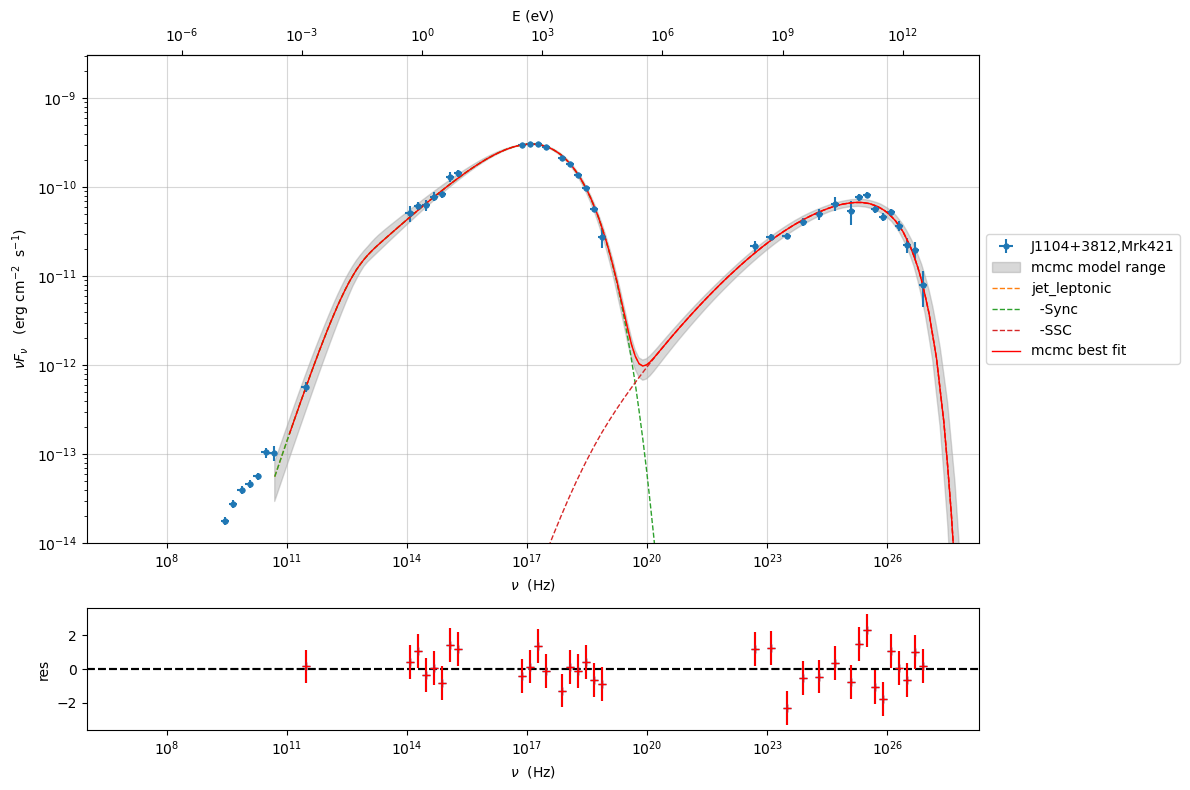

In [40]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=500,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

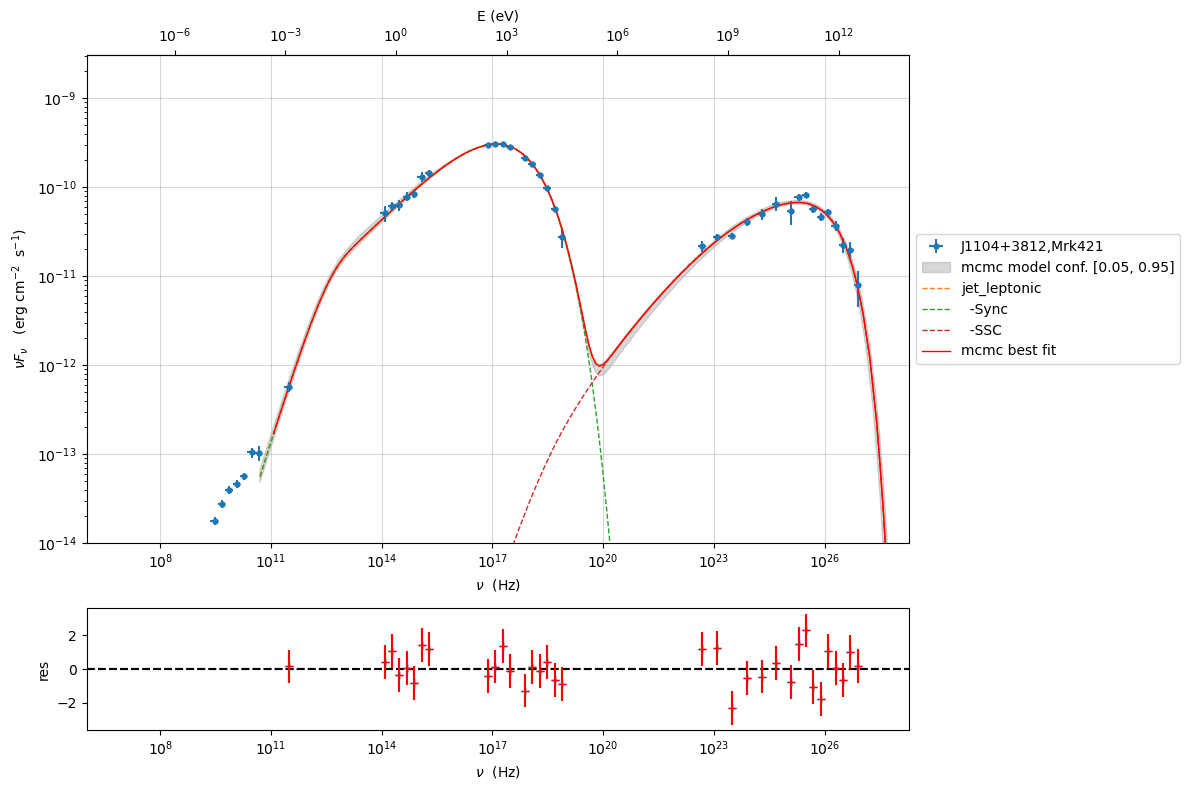

In [41]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

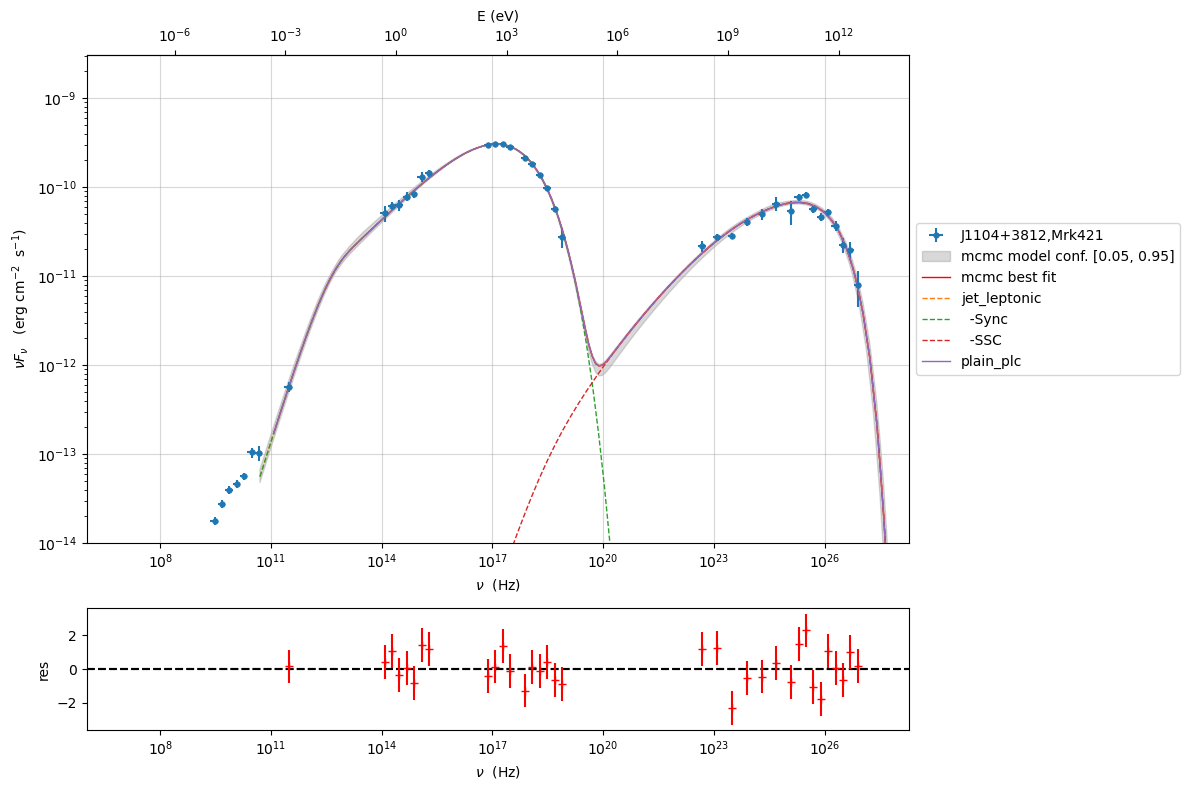

In [42]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95],plot_mcmc_best_fit_model=True)
p=ms.model.plot_model(plot_obj=p)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

Per-component corner plot

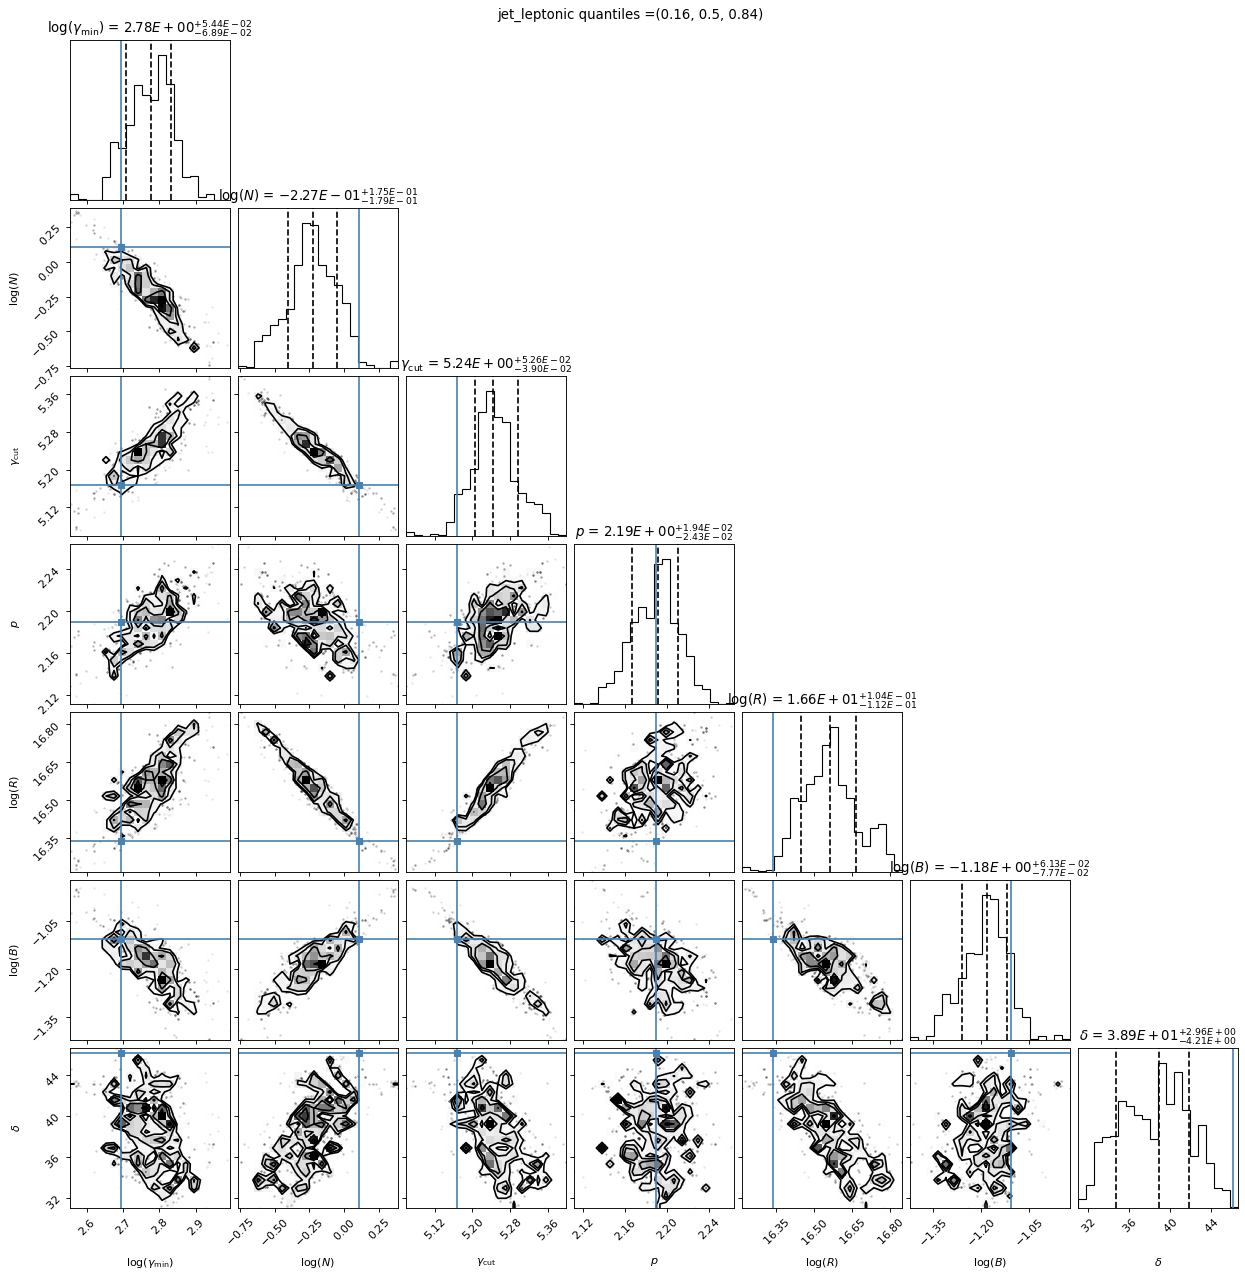

In [43]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

Global corner plot, pass `per_component=False`


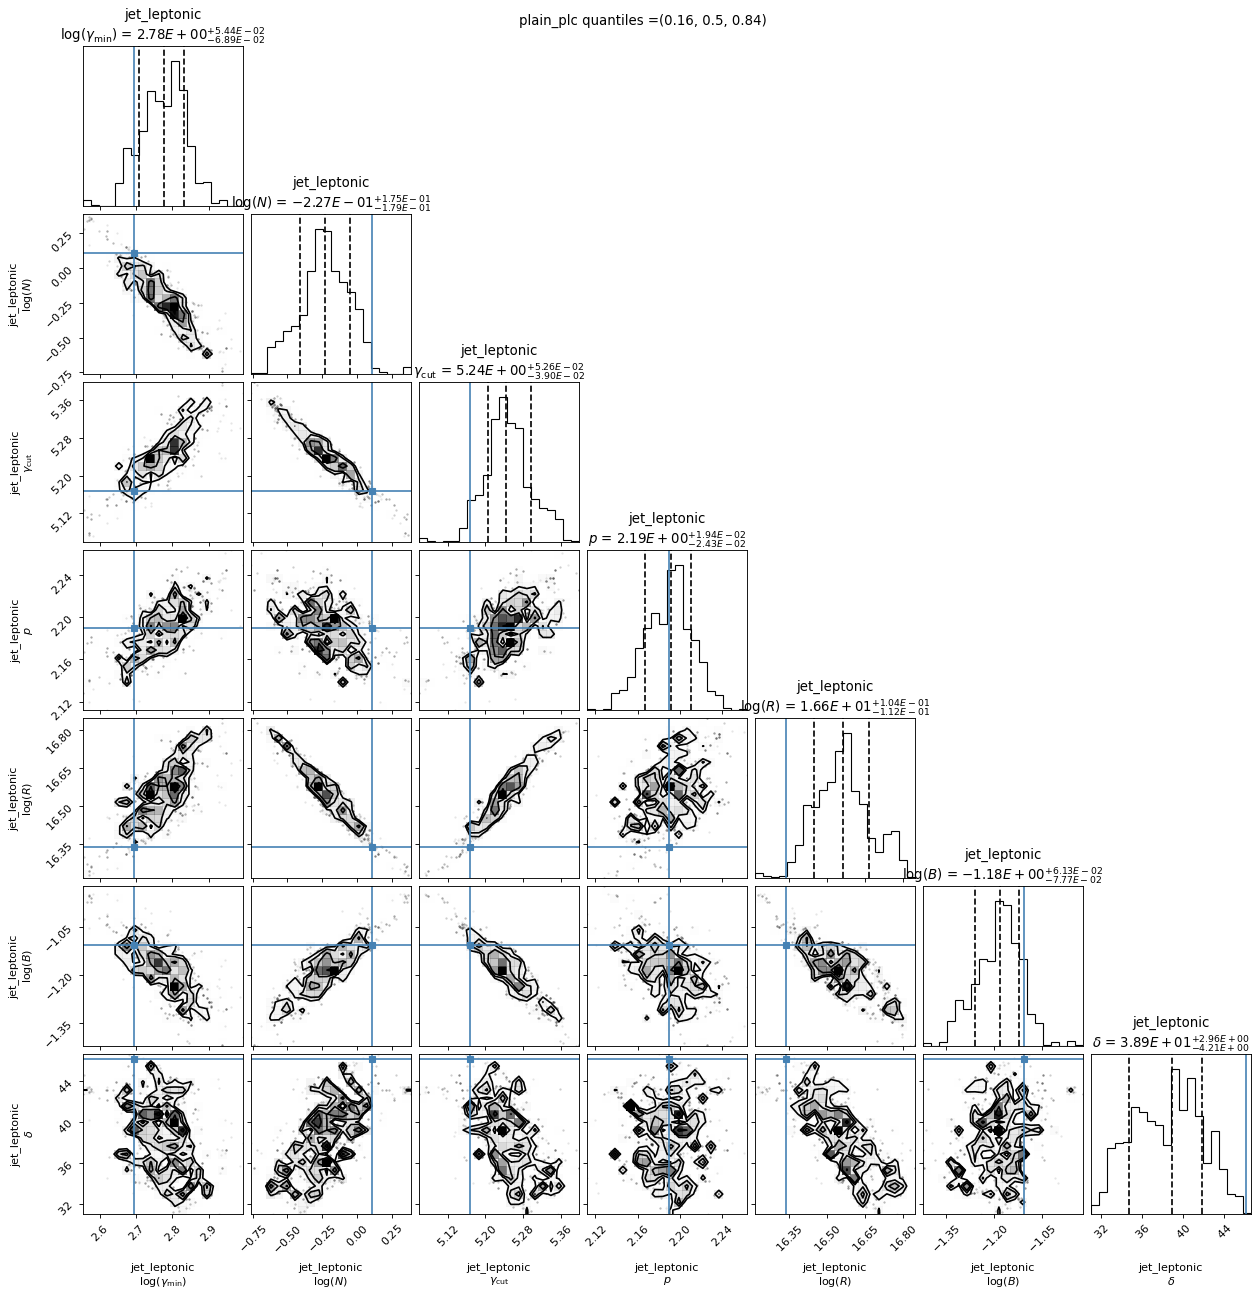

In [44]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True,per_component=False)